In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

what to try next,

1) make it into a full perturbation dataset (consider all genes perturbed), 
2) make a steady state dataset where values stay the same under no pertubation (0)
3) make a perturbation dataset where values stay as perturbed values

In [2]:
file_path = 'data/DREAM4 training data/insilico_size10_1/'
file_name = 'insilico_size10_1_timeseries'
num_file = 1
data_list = []
for i in range(num_file):
    data_list.append(pd.read_csv(file_path + file_name + f'.tsv', sep='\t'))

In [3]:
data_list[0]

,Time,G1,G2,G3,G4,G5,G6,G7,G8,G9,G10
0,0.0,0.666511,0.127219,0.355065,0.774572,0.100430,0.275493,0.606785,0.743098,0.665637,0.695064
1,50.0,0.325775,0.121822,0.346411,0.722911,0.192459,0.310764,0.609696,0.756752,0.555414,0.732717
2,100.0,0.177501,0.044359,0.571289,0.586828,0.233350,0.356974,0.464732,0.665699,0.721103,0.671716
3,150.0,0.183885,0.061535,0.484977,0.633821,0.404510,0.337567,0.420007,0.732409,0.640227,0.697043
4,200.0,0.093069,0.139843,0.343555,0.535438,0.558332,0.299423,0.414539,0.677147,0.547874,0.751275
...,...,...,...,...,...,...,...,...,...,...,...
100,800.0,0.710449,0.125061,0.344214,0.670873,0.078957,0.325078,0.332873,0.570205,0.576652,0.645182
101,850.0,0.678581,0.140996,0.230909,0.814594,0.124699,0.449799,0.410249,0.581812,0.727876,0.674584
102,900.0,0.560312,0.138841,0.243375,0.764173,0.109145,0.246595,0.511239,0.646766,0.813924,0.719532
103,950.0,0.609001,0.094110,0.307848,0.670791,0.140157,0.245498,0.582674,0.579840,0.705499,0.678587


In [7]:
genes = data_list[0].columns[1:]

In [5]:
data_list[0].iloc[40:45]

,Time,G1,G2,G3,G4,G5,G6,G7,G8,G9,G10
40,950.0,0.716418,0.081918,0.268504,0.796433,0.118092,0.296075,0.509237,0.712110,0.645482,0.661229
41,1000.0,0.803212,0.119864,0.314646,0.635287,0.180366,0.243231,0.537646,0.676355,0.625311,0.571694
42,0.0,0.702555,0.096541,0.495534,0.629004,0.139412,0.277728,0.585245,0.698731,0.718979,0.631701
43,50.0,0.267011,0.006640,0.412006,0.633102,0.160129,0.316089,0.387991,0.312542,0.840538,0.752593
44,100.0,0.149558,0.000203,0.316266,0.638811,0.352753,0.412145,0.537187,0.220712,0.784730,0.630808


In [22]:
chosen_genes = [["G1", "G4", "G5"], ["G1", "G4", "G7"],
                                     ["G1", "G5", "G8"],
                                     ["G1", "G2", "G3", "G4", "G6", "G7", "G8", "G9"],
                                     ["G4", "G7", "G9", "G10"]]

In [28]:
data_sets = []
time_length = 21
dataset_num = 5
for i in range(5):
    temp = data_list[0][genes].iloc[i*time_length:(i+1)*time_length].to_numpy()
    #print(data_list[0]["Time"].iloc[i*time_length:(i+1)*time_length])
    temp = temp.T
    
    data_sets.append(temp)

/tmp/ipykernel_43831/2272922210.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='best', fontsize='small', ncol=2)


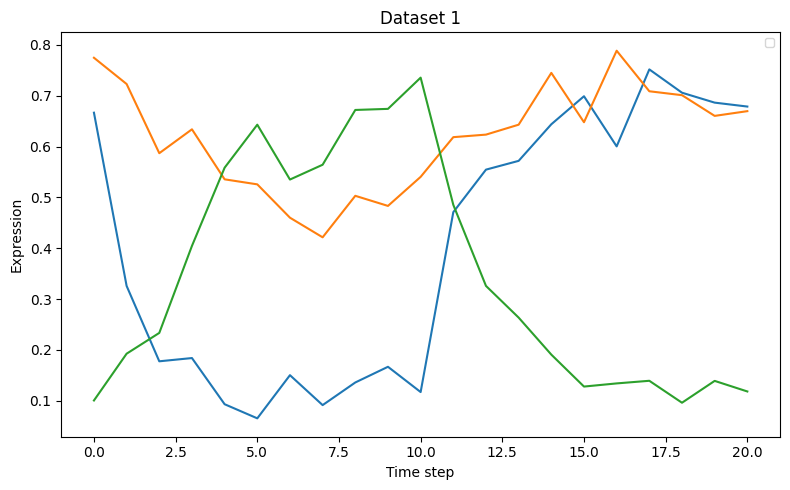

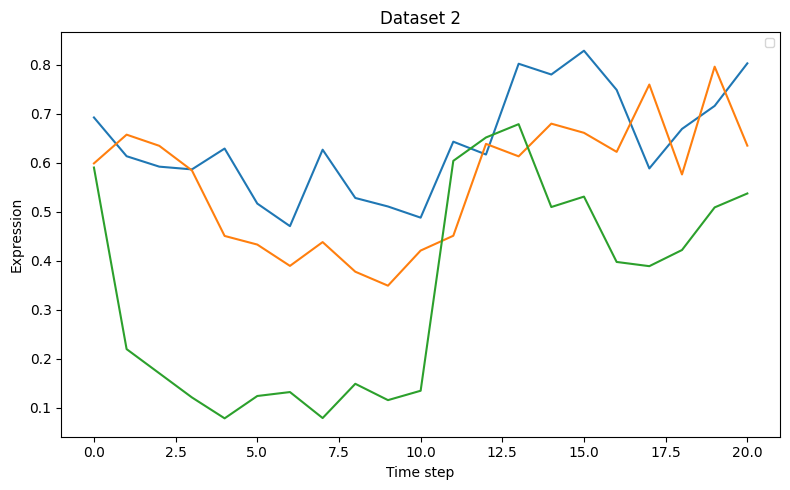

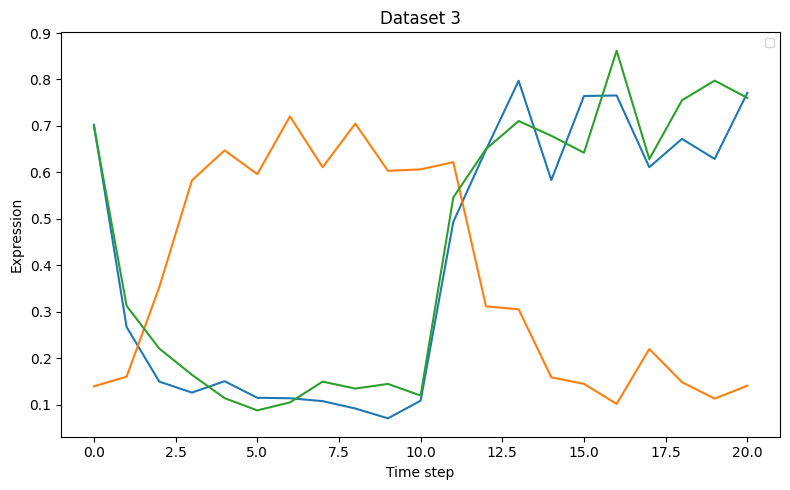

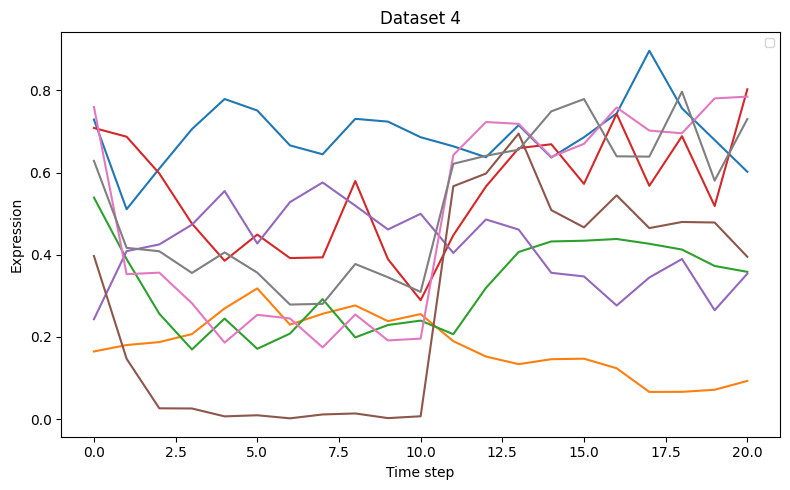

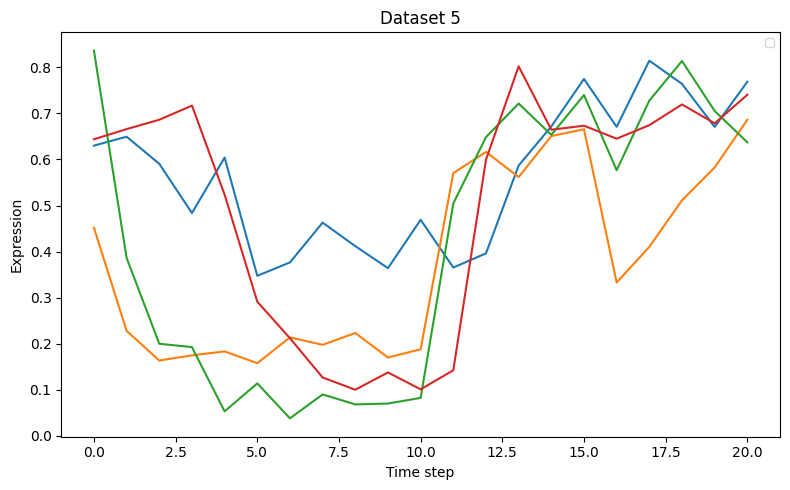

In [25]:
import matplotlib.pyplot as plt



for i in range(dataset_num):
    fig, ax = plt.subplots(figsize=(8, 5))
    
    plt.plot(data_sets[i].T)
    
    ax.set_xlabel("Time step")
    ax.set_ylabel("Expression")
    ax.set_title(f"Dataset {i+1}")
    ax.legend(loc='best', fontsize='small', ncol=2)
    fig.tight_layout()

plt.show()

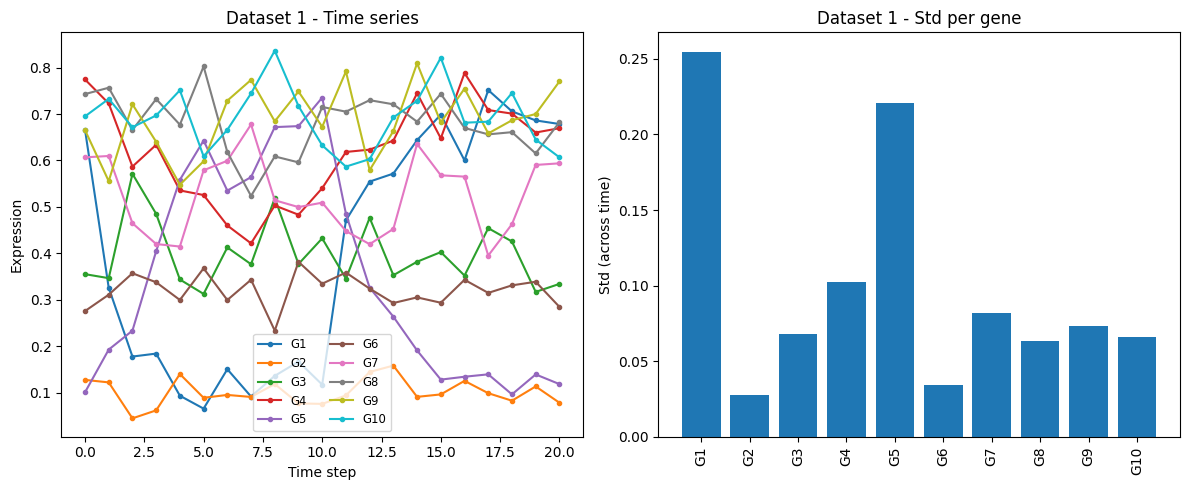

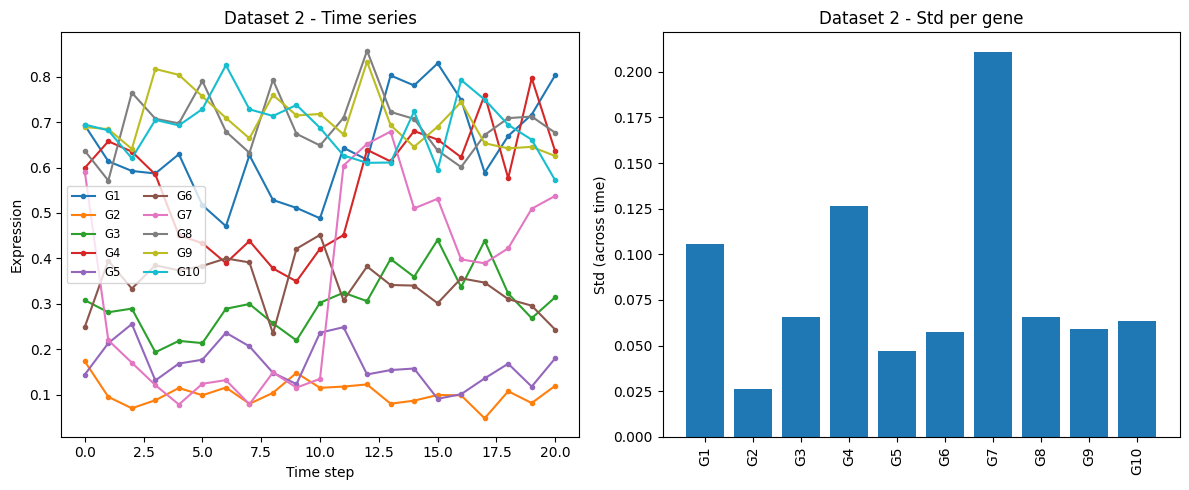

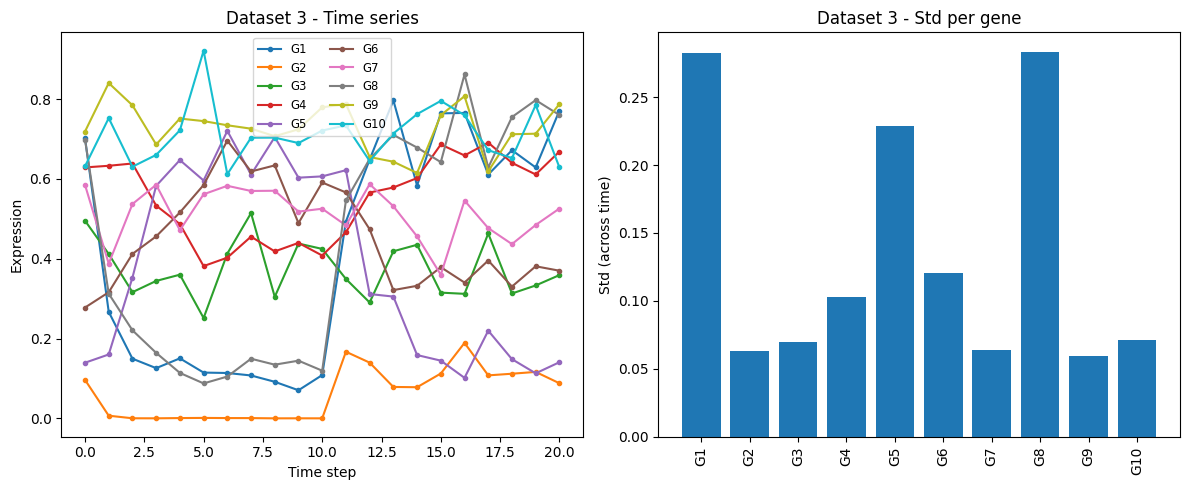

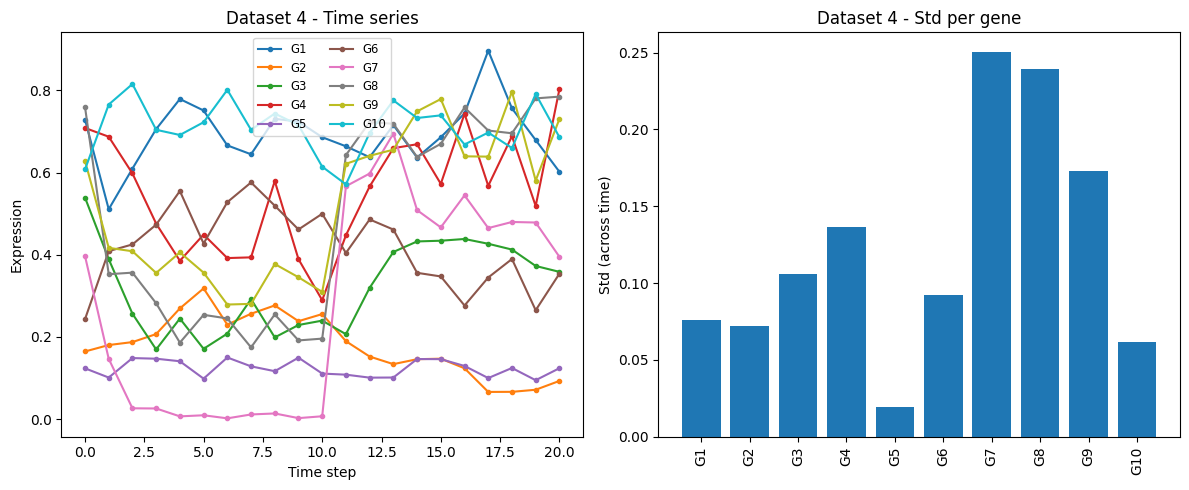

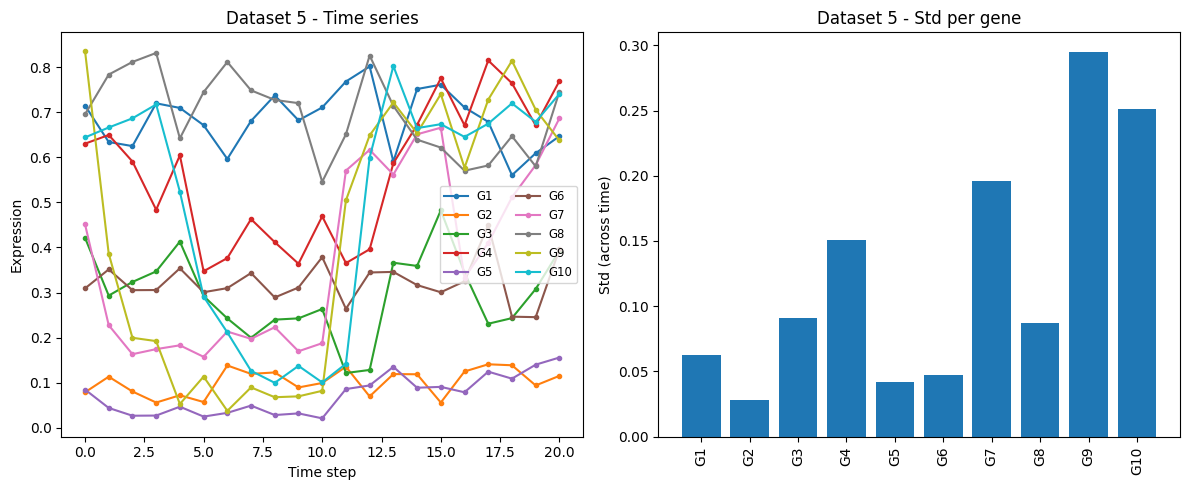

In [29]:
import matplotlib.pyplot as plt
import numpy as np

time_length = 21
dataset_num = 5

gene_stds = []  # will hold one (10,) array per dataset

for i in range(dataset_num):
    std_i = data_sets[i].std(axis=1)  # std across time, per gene -> shape (10,)
    gene_stds.append(std_i)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # time series
    ax1.plot(data_sets[i].T, marker='o', markersize=3)
    ax1.set_xlabel("Time step")
    ax1.set_ylabel("Expression")
    ax1.set_title(f"Dataset {i+1} - Time series")
    ax1.legend(genes, loc='best', fontsize='small', ncol=2)

    # std per gene
    ax2.bar(genes, std_i)
    ax2.set_ylabel("Std (across time)")
    ax2.set_title(f"Dataset {i+1} - Std per gene")
    ax2.tick_params(axis='x', rotation=90)

    fig.tight_layout()

plt.show()

In [27]:
from scipy.io import savemat

mat_dict = {f"X{i+1}": data_sets[i] for i in range(dataset_num)}
mat_dict['dt1'] = np.array([[50.0]])
savemat("DREAM10_01_subset.mat", mat_dict)

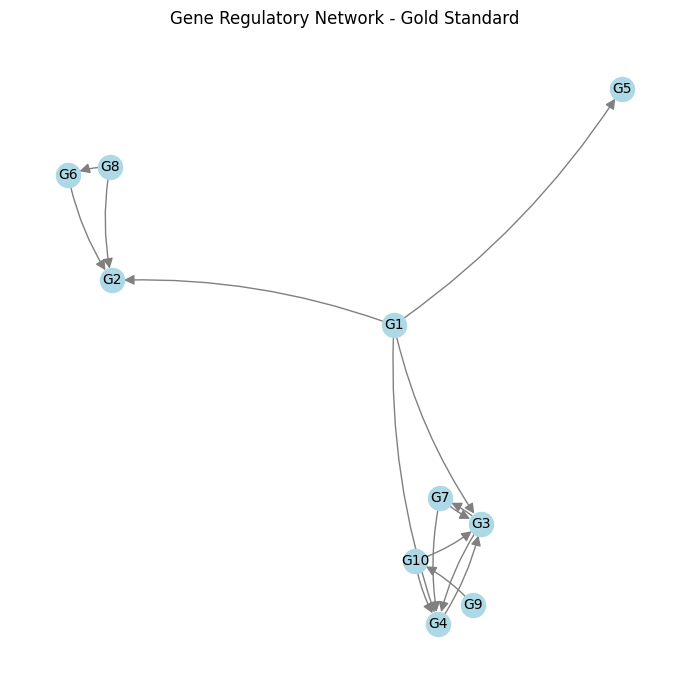

In [34]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
graph_path = 'data/DREAM4 gold standards/'
# read the file (no header, tab-separated)
df = pd.read_csv(graph_path + "insilico_size10_1_goldstandard.tsv", sep="\t", header=None,
                  names=["source", "target", "edge"])

# keep only actual edges
edges_df = df[df["edge"] == 1]

# build directed graph
G = nx.DiGraph()
G.add_nodes_from(df["source"].unique())  # ensure all genes appear as nodes, even isolated ones
G.add_nodes_from(df["target"].unique())
G.add_edges_from(zip(edges_df["source"], edges_df["target"]))

# plot
fig, ax = plt.subplots(figsize=(7, 7))
pos = nx.spring_layout(G, seed=42)  # fixed seed for reproducible layout

nx.draw_networkx_nodes(G, pos, node_color="lightblue", node_size=300, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, ax=ax)
nx.draw_networkx_edges(G, pos, edge_color="gray", arrows=True,
                        arrowsize=15, connectionstyle="arc3,rad=0.1", ax=ax)

ax.set_title("Gene Regulatory Network - Gold Standard")
ax.axis("off")
fig.tight_layout()
plt.show()

In [30]:
import numpy as np

# sort genes naturally (G1, G2, ..., G10) instead of lexicographically (G1, G10, G2, ...)
genes_sorted = sorted(G.nodes(), key=lambda g: int(g[1:]))

n = len(genes_sorted)
gene_to_idx = {gene: i for i, gene in enumerate(genes_sorted)}

adj_matrix = np.zeros((n, n), dtype=int)

for source, target in zip(edges_df["source"], edges_df["target"]):
    i, j = gene_to_idx[source], gene_to_idx[target]
    adj_matrix[i, j] = 1
    adj_matrix[j, i] = 1  # symmetric, direction ignored

print(genes_sorted)   # row/column order
print(adj_matrix)

['G1', 'G2', 'G3', 'G4', 'G5', 'G6', 'G7', 'G8', 'G9', 'G10']
[[0 1 1 1 1 0 0 0 0 0]
 [1 0 0 0 0 1 0 1 0 0]
 [1 0 0 1 0 0 1 0 0 1]
 [1 0 1 0 0 0 1 0 0 1]
 [1 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 1 0 0]
 [0 0 1 1 0 0 0 0 0 0]
 [0 1 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 0 1 1 0 0 0 0 1 0]]


In [31]:
ground_truth01 = {f"Ground_truth": adj_matrix}

savemat("DREAM10_01_groundtruth.mat", ground_truth01)

In [11]:
file_name = 'insilico_size10_1_wildtype'
num_file = 1
for i in range(num_file):
    data_list.append(pd.read_csv(file_path + file_name + f'.tsv', sep='\t'))

In [12]:
data_list[1]

,G1,G2,G3,G4,G5,G6,G7,G8,G9,G10
0,0.604682,0.123171,0.328794,0.604783,0.146485,0.325877,0.496733,0.649627,0.614085,0.748179


(array([1., 1., 1., 0., 1., 1., 0., 1., 2., 2.]),
 array([0.06156266, 0.07784716, 0.09413166, 0.11041616, 0.12670066,
        0.14298516, 0.15926966, 0.17555416, 0.19183866, 0.20812316,
        0.22440766]),
 <BarContainer object of 10 artists>)

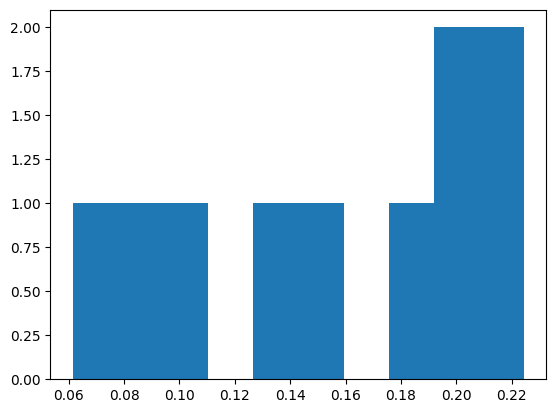

In [13]:
plt.hist(data_list[0][genes].std())

In [14]:
data_list[0][genes].std()

G1     0.224408
G2     0.061563
G3     0.091243
G4     0.128305
G5     0.191556
G6     0.094273
G7     0.202817
G8     0.208344
G9     0.201572
G10    0.150379
dtype: float64